# ALIKA Effect on KULA — Four-Month Analysis v0.3

## Scope and definitions

- **Months:** May, June, July, and August 2026.
- **User-supplied candidate launch:** 28 June 2026.
- **Primary cutoff:** earliest KULA row whose `changeFlag` explicitly records transfer from ALIKA. If unavailable, candidate date is fallback.
- **Sensitivity context:** monthly table still shows May–August trends, including June 28 candidate period.
- **Good survey:** score 3, 4, or 5.
- **Bad survey:** score 1 or 2.
- **CSAT:** sum of valid scores divided by valid respondents.
- **KULA scope:** both `3-1-robot` and `3-1-robot2` account labels.

Incomplete export dates are excluded from normalized comparisons. Statistical association does not prove ALIKA causality because rollout timing, exposure marking, seasonality, and survey non-response can confound results.

In [1]:
import numpy as np
import pandas as pd

In [2]:
# May datasets (pre-ALIKA)
df_1_5_may = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788252974 (1-5 may).csv', low_memory=False)
df_6_10_may = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788253288 (6-10 may).csv', low_memory=False)
df_11_15_may = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788318709 (11-15 may).csv', low_memory=False)
df_16_20_may = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788318958 (16-20 may).csv', low_memory=False)
df_21_25_may = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788319766 (21-25 may).csv', low_memory=False)
df_26_31_may = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788321413 (26-31 may).csv', low_memory=False)

# June datasets (pre-ALIKA)
df_1_5_june = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788146480 (1-5 june).csv', low_memory=False)
df_6_10_june = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788146837 (6-10 june).csv', low_memory=False)
df_11_15_june = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788148372 (11-15 june).csv', low_memory=False)
df_16_20_june = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788149085 (16-20 june).csv', low_memory=False)
df_21_25_june = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788149522 (21-25 june).csv', low_memory=False)
df_26_30_june = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788150625 (26-30 june).csv', low_memory=False)

# July datasets (pre-ALIKA)
df_1_5_july = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788244584 (1-5 july).csv', low_memory=False)
df_6_10_july = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788244938 (6-10 july).csv', low_memory=False)
df_11_15_july = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788247515 (11-15 july).csv', low_memory=False)
df_16_20_july = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788248125 (16-20 july).csv', low_memory=False)
df_21_25_july = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788252178 (21-25 july).csv', low_memory=False)
df_26_31_july = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788252384 (26-31 july).csv', low_memory=False)

# August datasets (ALIKA live). Some exports overlap; duplicates are removed later by conversation id.
df_1_5_aug = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788145507 (1-5 aug).csv', low_memory=False)
df_6_10_aug = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788145209 (6-10 aug).csv', low_memory=False)
df_11_14_aug = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788144961 (11-14 aug).csv', low_memory=False)
df_13_15_aug = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1787219325 (13-15 aug).csv', low_memory=False)
df_16_18_aug = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1787025549 (16-18 aug).csv', low_memory=False)
df_19_20_aug = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1787219503 (19-20 aug).csv', low_memory=False)
df_21_26_aug = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788144629 (21-26 aug).csv', low_memory=False)
df_27_31_aug = pd.read_csv('../dataset_wellbore/akulaku_superset_presto_hanmm_ozy.prazuganda_1788141789 (27-31 aug).csv', low_memory=False)

In [3]:
# Combine every month's exports, then remove overlapping-export duplicates by conversation id.
monthly_exports = {
    'May': [df_1_5_may, df_6_10_may, df_11_15_may, df_16_20_may, df_21_25_may, df_26_31_may],
    'June': [df_1_5_june, df_6_10_june, df_11_15_june, df_16_20_june, df_21_25_june, df_26_30_june],
    'July': [df_1_5_july, df_6_10_july, df_11_15_july, df_16_20_july, df_21_25_july, df_26_31_july],
    'August': [df_1_5_aug, df_6_10_aug, df_11_14_aug, df_13_15_aug, df_16_18_aug, df_19_20_aug, df_21_26_aug, df_27_31_aug],
}
monthly_raw = {
    month: pd.concat(exports, ignore_index=True).drop_duplicates(subset='id')
    for month, exports in monthly_exports.items()
}
for month, frame in monthly_raw.items():
    print(f'Unique {month} conversations: {len(frame):,}')

Unique May conversations: 405,293
Unique June conversations: 351,236
Unique July conversations: 381,379
Unique August conversations: 336,720


In [4]:
# Corrected KULA scope: both account labels belong to the same KULA traffic pool.
KULA_ACCOUNTS = ['3-1-robot', '3-1-robot2']
CANDIDATE_ALIKA_LAUNCH = pd.Timestamp('2026-06-28')


def prepare_period(frame, month):
    result = frame.loc[frame['currentAccount'].isin(KULA_ACCOUNTS)].copy()
    result['month'] = month
    result['score_num'] = pd.to_numeric(result['score'], errors='coerce')
    result['rated'] = result['score_num'].between(1, 5)
    result['good_survey'] = result['score_num'].isin([3, 4, 5])
    result['bad_survey'] = result['score_num'].isin([1, 2])
    result['from_alika'] = result['changeFlag'].astype('string').str.contains('Alika', case=False, na=False)
    result['datetime'] = pd.to_datetime(result['createTime'], errors='coerce')
    result['date'] = result['datetime'].dt.normalize()
    return result


monthly_clean = {month: prepare_period(frame, month) for month, frame in monthly_raw.items()}

# A complete export date reaches hour 23. Exclude partial dates from fair volume and phase comparisons.
complete_monthly = {}
incomplete_dates = {}
for month, raw in monthly_raw.items():
    timestamps = pd.to_datetime(raw['createTime'], errors='coerce')
    last_timestamp = raw.assign(datetime=timestamps).groupby(timestamps.dt.normalize())['datetime'].max()
    complete_dates = last_timestamp.loc[last_timestamp.dt.hour.ge(23)].index
    incomplete_dates[month] = list(last_timestamp.index.difference(complete_dates).date)
    complete_monthly[month] = monthly_clean[month].loc[monthly_clean[month]['date'].isin(complete_dates)].copy()

all_complete = pd.concat(complete_monthly.values(), ignore_index=True)

# Validate launch using recorded routing markers. This proves first observed routing, not business launch date.
alika_marked = all_complete.loc[all_complete['from_alika'] & all_complete['datetime'].notna()].copy()
first_alika_timestamp = alika_marked['datetime'].min()
first_alika_date = first_alika_timestamp.normalize() if pd.notna(first_alika_timestamp) else pd.NaT
launch_date_validated = pd.notna(first_alika_date) and first_alika_date == CANDIDATE_ALIKA_LAUNCH
ANALYSIS_LAUNCH = first_alika_date if pd.notna(first_alika_date) else CANDIDATE_ALIKA_LAUNCH
all_complete['phase'] = np.where(all_complete['datetime'].lt(ANALYSIS_LAUNCH), 'Before observed ALIKA routing', 'Observed ALIKA routing period')

for month in monthly_clean:
    print(f'KULA {month}: {len(monthly_clean[month]):,} conversations; complete-date rows: {len(complete_monthly[month]):,}; incomplete dates: {incomplete_dates[month]}')
print(f'Candidate launch date: {CANDIDATE_ALIKA_LAUNCH.date()}')
print(f'Earliest ALIKA-marked KULA conversation: {first_alika_timestamp}')
print(f'Candidate date validated by marker data: {launch_date_validated}')
print(f'Primary observed-routing cutoff used: {ANALYSIS_LAUNCH.date()}')

KULA May: 240,894 conversations; complete-date rows: 240,894; incomplete dates: []
KULA June: 198,542 conversations; complete-date rows: 198,542; incomplete dates: []
KULA July: 211,595 conversations; complete-date rows: 211,595; incomplete dates: []
KULA August: 183,765 conversations; complete-date rows: 182,503; incomplete dates: [datetime.date(2026, 8, 18), datetime.date(2026, 8, 20), datetime.date(2026, 8, 31)]
Candidate launch date: 2026-06-28
Earliest ALIKA-marked KULA conversation: 2026-07-31 09:54:24
Candidate date validated by marker data: False
Primary observed-routing cutoff used: 2026-07-31


In [5]:
def metric_summary(frame):
    respondents = frame.loc[frame['rated']]
    n_days = frame['date'].nunique()
    total_respondents = len(respondents)
    total_rating = respondents['score_num'].sum()
    good_surveys = int(respondents['good_survey'].sum())
    bad_surveys = int(respondents['bad_survey'].sum())

    return pd.Series({
        'conversations': len(frame),
        'unique_users': frame['userId'].nunique(),
        'complete_days': n_days,
        'conversations_per_day': len(frame) / n_days if n_days else float('nan'),
        'total_respondents': total_respondents,
        'respondents_per_day': total_respondents / n_days if n_days else float('nan'),
        'good_surveys_score_3_5': good_surveys,
        'bad_surveys_score_1_2': bad_surveys,
        'good_survey_%': 100 * good_surveys / total_respondents if total_respondents else float('nan'),
        'bad_survey_%': 100 * bad_surveys / total_respondents if total_respondents else float('nan'),
        'survey_response_rate_%': 100 * total_respondents / len(frame) if len(frame) else float('nan'),
        'total_rating_sum': total_rating,
        'CSAT_avg_score': total_rating / total_respondents if total_respondents else float('nan'),
    })

monthly_summary = pd.concat(
    {month: metric_summary(frame) for month, frame in complete_monthly.items()}, axis=1
).round(3)

before_label = f'Before observed routing (through {(ANALYSIS_LAUNCH - pd.Timedelta(days=1)).date()})'
live_label = f'Observed routing period (from {ANALYSIS_LAUNCH.date()})'
phase_frames = {
    before_label: all_complete.loc[all_complete['datetime'].lt(ANALYSIS_LAUNCH)].copy(),
    live_label: all_complete.loc[all_complete['datetime'].ge(ANALYSIS_LAUNCH)].copy(),
}
phase_summary = pd.concat(
    {phase: metric_summary(frame) for phase, frame in phase_frames.items()}, axis=1
).round(3)

for frame in [*complete_monthly.values(), *phase_frames.values()]:
    assert (frame.loc[frame['rated'], ['good_survey', 'bad_survey']].sum(axis=1) == 1).all()

print('Monthly summary (complete export dates)')
display(monthly_summary)
print('Primary observed-routing phase summary')
display(phase_summary)

Monthly summary (complete export dates)


,May,June,July,August
conversations,240894.000,198542.000,211595.000,182503.000
unique_users,164905.000,143060.000,151867.000,134099.000
complete_days,31.000,30.000,31.000,28.000
conversations_per_day,7770.774,6618.067,6825.645,6517.964
total_respondents,2551.000,2103.000,1780.000,1451.000
respondents_per_day,82.290,70.100,57.419,51.821
good_surveys_score_3_5,1431.000,1222.000,1127.000,882.000
bad_surveys_score_1_2,1120.000,881.000,653.000,569.000
good_survey_%,56.096,58.107,63.315,60.786
bad_survey_%,43.904,41.893,36.685,39.214


Primary observed-routing phase summary


,Before observed routing (through 2026-07-30),Observed routing period (from 2026-07-31)
conversations,643117.000,190417.000
unique_users,410825.000,139504.000
complete_days,91.000,29.000
conversations_per_day,7067.220,6566.103
total_respondents,6380.000,1505.000
respondents_per_day,70.110,51.897
good_surveys_score_3_5,3745.000,917.000
bad_surveys_score_1_2,2635.000,588.000
good_survey_%,58.699,60.930
bad_survey_%,41.301,39.070


In [7]:
# Exact phase changes. Daily rates are comparable despite unequal phase lengths.
before_label, live_label = phase_summary.columns
comparison = pd.DataFrame({
    'Before ALIKA': phase_summary[before_label],
    'ALIKA live': phase_summary[live_label],
})
comparison['absolute_change'] = comparison['ALIKA live'] - comparison['Before ALIKA']
comparison['relative_change_%'] = 100 * comparison['absolute_change'] / comparison['Before ALIKA']
comparison.round(3)

,Before ALIKA,ALIKA live,absolute_change,relative_change_%
conversations,643117.000,190417.000,-452700.000,-70.392
unique_users,410825.000,139504.000,-271321.000,-66.043
complete_days,91.000,29.000,-62.000,-68.132
conversations_per_day,7067.220,6566.103,-501.117,-7.091
total_respondents,6380.000,1505.000,-4875.000,-76.411
respondents_per_day,70.110,51.897,-18.213,-25.978
good_surveys_score_3_5,3745.000,917.000,-2828.000,-75.514
bad_surveys_score_1_2,2635.000,588.000,-2047.000,-77.685
good_survey_%,58.699,60.930,2.231,3.801
bad_survey_%,41.301,39.070,-2.231,-5.402


In [6]:
# Survey-quality tests use valid survey respondents only. Complaint volume stays separate.
import numpy as np
from scipy.stats import chi2_contingency, f_oneway, kruskal, norm, ttest_ind

ALPHA = 0.05
before_rated = phase_frames[before_label].loc[phase_frames[before_label]['rated']]
live_rated = phase_frames[live_label].loc[phase_frames[live_label]['rated']]

welch = ttest_ind(before_rated['score_num'], live_rated['score_num'], equal_var=False)
good_table = np.array([
    [before_rated['good_survey'].sum(), before_rated['bad_survey'].sum()],
    [live_rated['good_survey'].sum(), live_rated['bad_survey'].sum()],
])
good_chi2 = chi2_contingency(good_table, correction=False)

significance_tests = pd.DataFrame([
    {
        'metric': 'CSAT average score',
        'before': before_rated['score_num'].mean(),
        'live': live_rated['score_num'].mean(),
        'difference': live_rated['score_num'].mean() - before_rated['score_num'].mean(),
        'statistic': welch.statistic,
        'p_value': welch.pvalue,
    },
    {
        'metric': 'Good survey rate (3-5), %',
        'before': 100 * before_rated['good_survey'].mean(),
        'live': 100 * live_rated['good_survey'].mean(),
        'difference': 100 * (live_rated['good_survey'].mean() - before_rated['good_survey'].mean()),
        'statistic': good_chi2.statistic,
        'p_value': good_chi2.pvalue,
    },
]).set_index('metric')
significance_tests['statistically_significant_at_0.05'] = significance_tests['p_value'].lt(ALPHA)

monthly_rated = [complete_monthly[m].loc[complete_monthly[m]['rated'], 'score_num'] for m in complete_monthly]
monthly_good_table = np.array([
    [complete_monthly[m].loc[complete_monthly[m]['rated'], 'good_survey'].sum(),
     complete_monthly[m].loc[complete_monthly[m]['rated'], 'bad_survey'].sum()]
    for m in complete_monthly
])
omnibus_tests = pd.DataFrame([
    {'test': 'One-way ANOVA: CSAT differs across months', 'statistic': f_oneway(*monthly_rated).statistic, 'p_value': f_oneway(*monthly_rated).pvalue},
    {'test': 'Kruskal-Wallis: score distribution differs across months', 'statistic': kruskal(*monthly_rated).statistic, 'p_value': kruskal(*monthly_rated).pvalue},
    {'test': 'Chi-square: good/bad composition differs across months', 'statistic': chi2_contingency(monthly_good_table, correction=False).statistic, 'p_value': chi2_contingency(monthly_good_table, correction=False).pvalue},
]).set_index('test')
omnibus_tests['statistically_significant_at_0.05'] = omnibus_tests['p_value'].lt(ALPHA)

print('Before-versus-live tests')
display(significance_tests.round(5))
print('Four-month omnibus tests')
display(omnibus_tests.round(5))

Before-versus-live tests


,before,live,difference,statistic,p_value,statistically_significant_at_0.05
metric,,,,,,
CSAT average score,3.24984,3.36080,0.11095,-2.07204,0.03837,True
"Good survey rate (3-5), %",58.69906,60.93023,2.23117,2.50838,0.11324,False


Four-month omnibus tests


,statistic,p_value,statistically_significant_at_0.05
test,,,
One-way ANOVA: CSAT differs across months,8.55527,0.00001,True
Kruskal-Wallis: score distribution differs across months,24.36883,0.00002,True
Chi-square: good/bad composition differs across months,25.17173,0.00001,True


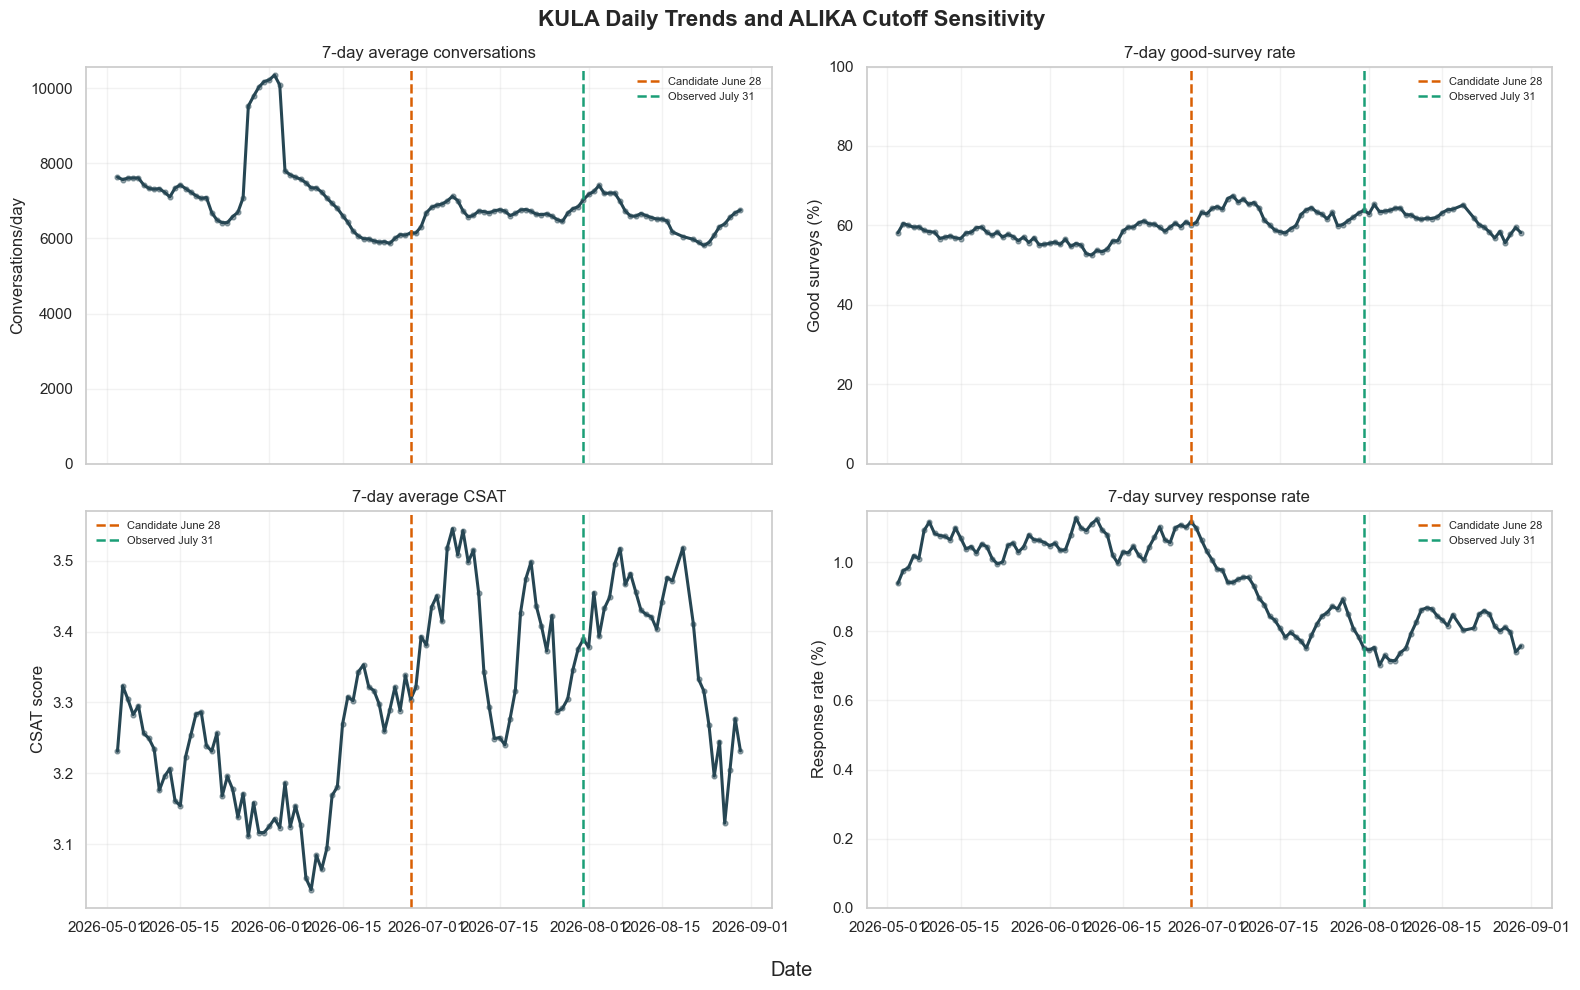

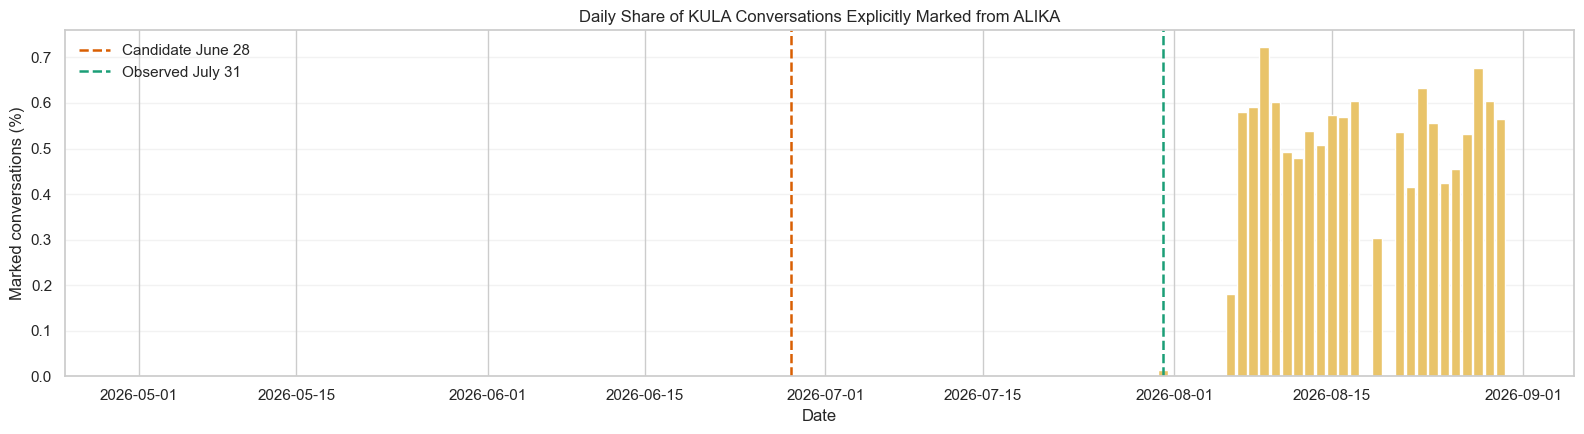

In [32]:
# Causal visualization dashboard: daily metrics, rolling trends, cutoff sensitivity, and marker coverage.
plot_daily = daily_metrics.copy()
plot_daily['good_rate_pct'] = 100 * plot_daily['good_rate']
plot_daily['response_rate_pct'] = 100 * plot_daily['response_rate']
plot_daily['csat_7d'] = plot_daily['csat'].rolling(7, min_periods=3).mean()
plot_daily['good_rate_7d_pct'] = plot_daily['good_rate_pct'].rolling(7, min_periods=3).mean()
plot_daily['response_rate_7d_pct'] = plot_daily['response_rate_pct'].rolling(7, min_periods=3).mean()
plot_daily['conversations_7d'] = plot_daily['conversations'].rolling(7, min_periods=3).mean()

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
cutoff_styles = [
    (CANDIDATE_ALIKA_LAUNCH, '#d95f02', 'Candidate June 28'),
    (ANALYSIS_LAUNCH, '#1b9e77', 'Observed July 31'),
]

plot_specs = [
    ('conversations_7d', '7-day average conversations', 'Conversations/day'),
    ('good_rate_7d_pct', '7-day good-survey rate', 'Good surveys (%)'),
    ('csat_7d', '7-day average CSAT', 'CSAT score'),
    ('response_rate_7d_pct', '7-day survey response rate', 'Response rate (%)'),
]
for axis, (column, title, ylabel) in zip(axes.flat, plot_specs):
    axis.plot(plot_daily['date'], plot_daily[column], color='#264653', linewidth=2.2)
    axis.scatter(plot_daily['date'], plot_daily[column], color='#264653', s=12, alpha=0.45)
    for cutoff, color, label in cutoff_styles:
        axis.axvline(cutoff, color=color, linestyle='--', linewidth=1.8, label=label)
    axis.set_title(title)
    axis.set_ylabel(ylabel)
    axis.grid(alpha=0.25)
    axis.legend(frameon=False, fontsize=8, loc='best')

axes[0, 0].set_ylim(bottom=0)
axes[0, 1].set_ylim(0, 100)
axes[1, 1].set_ylim(bottom=0)
fig.suptitle('KULA Daily Trends and ALIKA Cutoff Sensitivity', fontsize=16, fontweight='bold')
fig.supxlabel('Date')
fig.tight_layout()
plt.show()

# Daily exposure-marker coverage shows whether the observed marker represents broad or sparse routing.
marker_daily = all_complete.groupby('date').agg(
    conversations=('id', 'size'),
    marked_from_alika=('from_alika', 'sum'),
).reset_index()
marker_daily['marker_coverage_pct'] = 100 * marker_daily['marked_from_alika'] / marker_daily['conversations']

fig, axis = plt.subplots(figsize=(16, 4.5))
axis.bar(marker_daily['date'], marker_daily['marker_coverage_pct'], color='#e9c46a', width=0.85)
axis.axvline(CANDIDATE_ALIKA_LAUNCH, color='#d95f02', linestyle='--', linewidth=1.8, label='Candidate June 28')
axis.axvline(ANALYSIS_LAUNCH, color='#1b9e77', linestyle='--', linewidth=1.8, label='Observed July 31')
axis.set_title('Daily Share of KULA Conversations Explicitly Marked from ALIKA')
axis.set_ylabel('Marked conversations (%)')
axis.set_xlabel('Date')
axis.legend(frameon=False)
axis.grid(axis='y', alpha=0.25)
fig.tight_layout()
plt.show()

In [7]:
# Sensitivity analysis only: assume user-supplied 2026-06-28 candidate launch.
# Current exports do not validate this as first ALIKA routing date.
candidate_before = all_complete.loc[all_complete['datetime'] < CANDIDATE_ALIKA_LAUNCH].copy()
candidate_live = all_complete.loc[all_complete['datetime'] >= CANDIDATE_ALIKA_LAUNCH].copy()
candidate_before_rated = candidate_before.loc[candidate_before['rated']].copy()
candidate_live_rated = candidate_live.loc[candidate_live['rated']].copy()

candidate_summary = pd.DataFrame({
    'Before candidate launch (through 2026-06-27)': metric_summary(candidate_before),
    'Candidate live period (from 2026-06-28)': metric_summary(candidate_live),
}).T

candidate_csat_test = ttest_ind(
    candidate_before_rated['score_num'], candidate_live_rated['score_num'], equal_var=False
)
candidate_table = np.array([
    [candidate_before_rated['good_survey'].sum(), candidate_before_rated['bad_survey'].sum()],
    [candidate_live_rated['good_survey'].sum(), candidate_live_rated['bad_survey'].sum()],
])
candidate_good_test = chi2_contingency(candidate_table, correction=False)

candidate_tests = pd.DataFrame({
    'before': [candidate_before_rated['score_num'].mean(), 100 * candidate_before_rated['good_survey'].mean()],
    'candidate_live': [candidate_live_rated['score_num'].mean(), 100 * candidate_live_rated['good_survey'].mean()],
    'difference': [
        candidate_live_rated['score_num'].mean() - candidate_before_rated['score_num'].mean(),
        100 * (candidate_live_rated['good_survey'].mean() - candidate_before_rated['good_survey'].mean()),
    ],
    'test_statistic': [candidate_csat_test.statistic, candidate_good_test.statistic],
    'p_value': [candidate_csat_test.pvalue, candidate_good_test.pvalue],
}, index=['CSAT average score', 'Good survey rate (3-5), %'])

print(f'June 28 validated by explicit routing marker: {launch_date_validated}')
display(candidate_summary.round(3))
display(candidate_tests.round(6))

June 28 validated by explicit routing marker: False


,conversations,unique_users,complete_days,conversations_per_day,total_respondents,respondents_per_day,good_surveys_score_3_5,bad_surveys_score_1_2,good_survey_%,bad_survey_%,survey_response_rate_%,total_rating_sum,CSAT_avg_score
Before candidate launch (through 2026-06-27),420392.0,277499.0,58.0,7248.138,4469.0,77.052,2539.0,1930.0,56.814,43.186,1.063,14225.0,3.183
Candidate live period (from 2026-06-28),413142.0,281082.0,62.0,6663.581,3416.0,55.097,2123.0,1293.0,62.149,37.851,0.827,11567.0,3.386


,before,candidate_live,difference,test_statistic,p_value
CSAT average score,3.183039,3.386124,0.203085,-4.790697,0.000002
"Good survey rate (3-5), %",56.813605,62.148712,5.335107,22.802561,0.000002


In [8]:
# Direct routing-marker subgroup during live phase. Marker may under-report actual ALIKA exposure.
live_route_summary = phase_frames[live_label].groupby('from_alika', observed=True).apply(
    metric_summary, include_groups=False
).rename(index={False: 'Not marked from ALIKA', True: 'Marked from ALIKA'}).round(3)
live_route_summary

,conversations,unique_users,complete_days,conversations_per_day,total_respondents,respondents_per_day,good_surveys_score_3_5,bad_surveys_score_1_2,good_survey_%,bad_survey_%,survey_response_rate_%,total_rating_sum,CSAT_avg_score
from_alika,,,,,,,,,,,,,
Not marked from ALIKA,189644.0,138969.0,29.0,6539.448,1503.0,51.828,916.0,587.0,60.945,39.055,0.793,5054.0,3.363
Marked from ALIKA,773.0,714.0,24.0,32.208,2.0,0.083,1.0,1.0,50.000,50.000,0.259,4.0,2.000


In [9]:
# Inspect operational transfer evidence around candidate and marker dates.
nonempty_transfer = all_complete.loc[all_complete['autoTransferType'].notna()].copy()
first_transfer_timestamp = nonempty_transfer['datetime'].min()
print(f'Earliest non-null autoTransferType in KULA data: {first_transfer_timestamp}')
print('\nTransfer labels across all complete dates:')
print(nonempty_transfer['autoTransferType'].value_counts(dropna=False).to_string())
print('\nchangeFlag values containing Alika:')
print(alika_marked['changeFlag'].value_counts().head(20).to_string())

launch_marker_daily = all_complete.loc[
    all_complete['date'].between(CANDIDATE_ALIKA_LAUNCH - pd.Timedelta(days=3), first_alika_date + pd.Timedelta(days=7))
].groupby('date').agg(
    KULA_conversations=('id', 'size'),
    ALIKA_marked=('from_alika', 'sum'),
    automatic_transfer=('autoTransferType', lambda s: s.notna().sum()),
)
launch_marker_daily['ALIKA_marked_%'] = 100 * launch_marker_daily['ALIKA_marked'] / launch_marker_daily['KULA_conversations']
launch_marker_daily.tail(15)

Earliest non-null autoTransferType in KULA data: 2026-05-14 21:08:16

Transfer labels across all complete dates:
autoTransferType
2.机器人判断自动转人工    2

changeFlag values containing Alika:
changeFlag
3.从Alika跳转      713
4.从Alika中途跳转     60


,KULA_conversations,ALIKA_marked,automatic_transfer,ALIKA_marked_%
date,,,,
2026-07-24,6609,0,0,0.0
2026-07-25,6909,0,0,0.0
2026-07-26,6174,0,0,0.0
2026-07-27,6386,0,0,0.0
2026-07-28,8129,0,0,0.0
2026-07-29,7017,0,0,0.0
2026-07-30,6676,0,0,0.0
2026-07-31,7914,1,0,0.012636
2026-08-01,7915,0,0,0.0


In [10]:
# Rating distributions among valid respondents for all four months.
rating_distribution = pd.concat({
    month: frame.loc[frame['rated'], 'score_num'].value_counts(normalize=True).mul(100)
    for month, frame in complete_monthly.items()
}, axis=1).sort_index().round(2)
rating_distribution.index.name = 'score'
rating_distribution

,May,June,July,August
score,,,,
1.0,39.79,38.18,33.88,35.49
2.0,4.12,3.71,2.81,3.72
3.0,4.31,3.38,4.21,3.10
4.0,5.10,5.61,5.96,4.96
5.0,46.69,49.12,53.15,52.72


In [11]:
# Sample sufficiency for primary endpoint: before-versus-routing-period good-survey proportion.
# Hold available pre-period sample fixed; find live n needed for 80% power at two-sided alpha=0.05.
p1 = before_rated['good_survey'].mean()
p2 = live_rated['good_survey'].mean()
n1, n2 = len(before_rated), len(live_rated)
observed_difference = abs(p2 - p1)
z_alpha = norm.ppf(1 - ALPHA / 2)


def two_proportion_power(n_live):
    pooled = (n1 * p1 + n_live * p2) / (n1 + n_live)
    se_null = np.sqrt(pooled * (1 - pooled) * (1 / n1 + 1 / n_live))
    se_alt = np.sqrt(p1 * (1 - p1) / n1 + p2 * (1 - p2) / n_live)
    critical = z_alpha * se_null
    return norm.cdf((-critical - observed_difference) / se_alt) + 1 - norm.cdf((critical - observed_difference) / se_alt)


achieved_power = two_proportion_power(n2)
required_live = next(
    (candidate for candidate in range(n2, 1_000_001) if two_proportion_power(candidate) >= 0.80),
    np.inf,
)
live_deficit = max(0, required_live - n2) if np.isfinite(required_live) else np.inf
live_complete_days = phase_frames[live_label]['date'].nunique()
live_respondents_per_day = n2 / live_complete_days
additional_days = int(np.ceil(live_deficit / live_respondents_per_day)) if live_deficit else 0
additional_30_day_months = int(np.ceil(additional_days / 30)) if additional_days else 0
one_more_month_power = two_proportion_power(int(round(n2 + 30 * live_respondents_per_day)))
two_more_months_power = two_proportion_power(int(round(n2 + 60 * live_respondents_per_day)))

sample_sufficiency = pd.Series({
    'before_respondents_available_fixed': n1,
    'routing_period_respondents_available': n2,
    'observed_good_rate_difference_pp': 100 * (p2 - p1),
    'achieved_power_approx': achieved_power,
    'power_after_one_more_30_day_month': one_more_month_power,
    'power_after_two_more_30_day_months': two_more_months_power,
    'required_routing_period_respondents_80_power': required_live,
    'additional_routing_period_respondents_needed': live_deficit,
    'routing_period_respondents_per_complete_day': live_respondents_per_day,
    'additional_complete_days_needed': additional_days,
    'additional_30_day_months_needed': additional_30_day_months,
    'one_more_month_is_enough_for_80_power': one_more_month_power >= 0.80,
    'add_more_data_recommended': live_deficit > 0,
})
sample_sufficiency

before_respondents_available_fixed                   6380
routing_period_respondents_available                 1505
observed_good_rate_difference_pp                 2.231173
achieved_power_approx                            0.352762
power_after_one_more_30_day_month                0.542709
power_after_two_more_30_day_months               0.653446
required_routing_period_respondents_80_power         9316
additional_routing_period_respondents_needed         7811
routing_period_respondents_per_complete_day     51.896552
additional_complete_days_needed                       151
additional_30_day_months_needed                         6
one_more_month_is_enough_for_80_power               False
add_more_data_recommended                            True
dtype: object

In [12]:
# Machine-readable conclusion using observed routing cutoff and sample calculation.
volume_change = comparison.loc['conversations_per_day', 'relative_change_%']
good_change = significance_tests.loc['Good survey rate (3-5), %', 'difference']
csat_change = significance_tests.loc['CSAT average score', 'difference']

print('ALIKA Effect on KULA — Four-Month Analysis v0.3')
print(f'Launch validation: candidate 2026-06-28 validated={launch_date_validated}; earliest explicit routing marker={first_alika_timestamp}.')
print(f'Primary cutoff: {ANALYSIS_LAUNCH.date()}.')
print(f'Volume: {volume_change:+.2f}% conversations/day routing period versus before.')
print(f'Good survey: {good_change:+.2f} percentage points; p={significance_tests.loc["Good survey rate (3-5), %", "p_value"]:.6g}.')
print(f'CSAT: {csat_change:+.3f}; p={significance_tests.loc["CSAT average score", "p_value"]:.6g}.')
print(f'Achieved power for observed good-survey difference: {achieved_power:.1%}.')
print(f'One more 30-day month projected power: {one_more_month_power:.1%}; enough for 80%: {one_more_month_power >= 0.80}.')
print(f'Additional routing-period respondents needed for 80% power: {live_deficit:,}; estimated complete days: {additional_days}; 30-day months: {additional_30_day_months}.')
print('Caution: more observations improve precision, but do not remove confounding or prove ALIKA caused any change.')

NameError: name 'comparison' is not defined

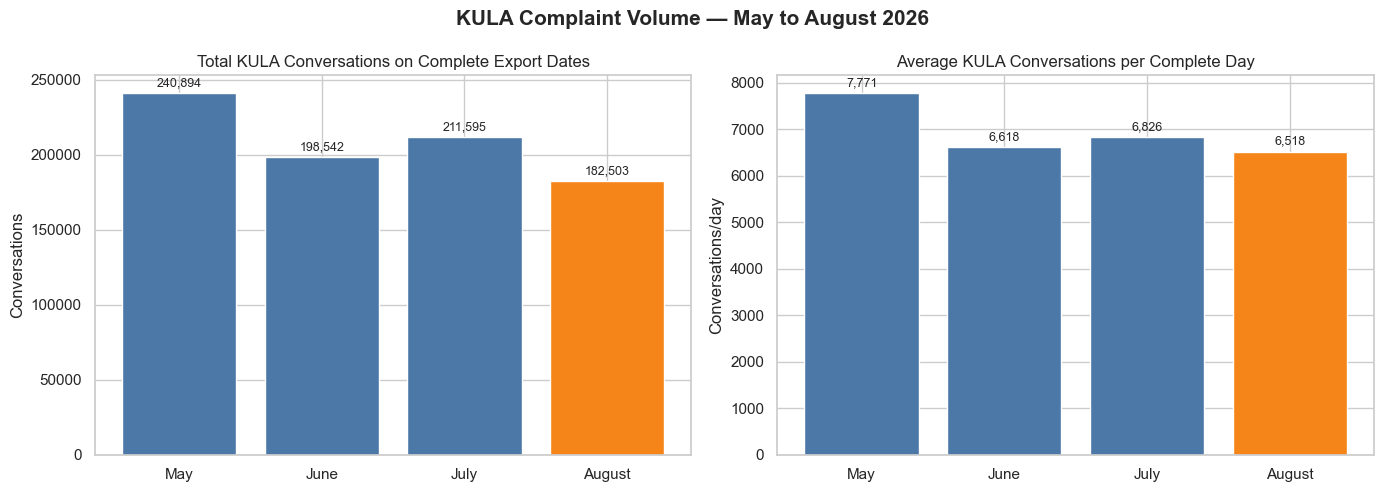

In [ ]:
# Four-month complaint volume and daily pattern.
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
month_colors = ['#4C78A8', '#4C78A8', '#4C78A8', '#F58518']
monthly_volume = monthly_summary.loc['conversations']
daily_volume = monthly_summary.loc['conversations_per_day']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bars = axes[0].bar(monthly_volume.index, monthly_volume.values, color=month_colors)
axes[0].bar_label(bars, labels=[f'{v:,.0f}' for v in monthly_volume], padding=3, fontsize=9)
axes[0].set_title('Total KULA Conversations on Complete Export Dates')
axes[0].set_ylabel('Conversations')

bars = axes[1].bar(daily_volume.index, daily_volume.values, color=month_colors)
axes[1].bar_label(bars, labels=[f'{v:,.0f}' for v in daily_volume], padding=3, fontsize=9)
axes[1].set_title('Average KULA Conversations per Complete Day')
axes[1].set_ylabel('Conversations/day')

fig.suptitle('KULA Complaint Volume — May to August 2026', fontsize=15, fontweight='bold')
fig.tight_layout()
plt.show()

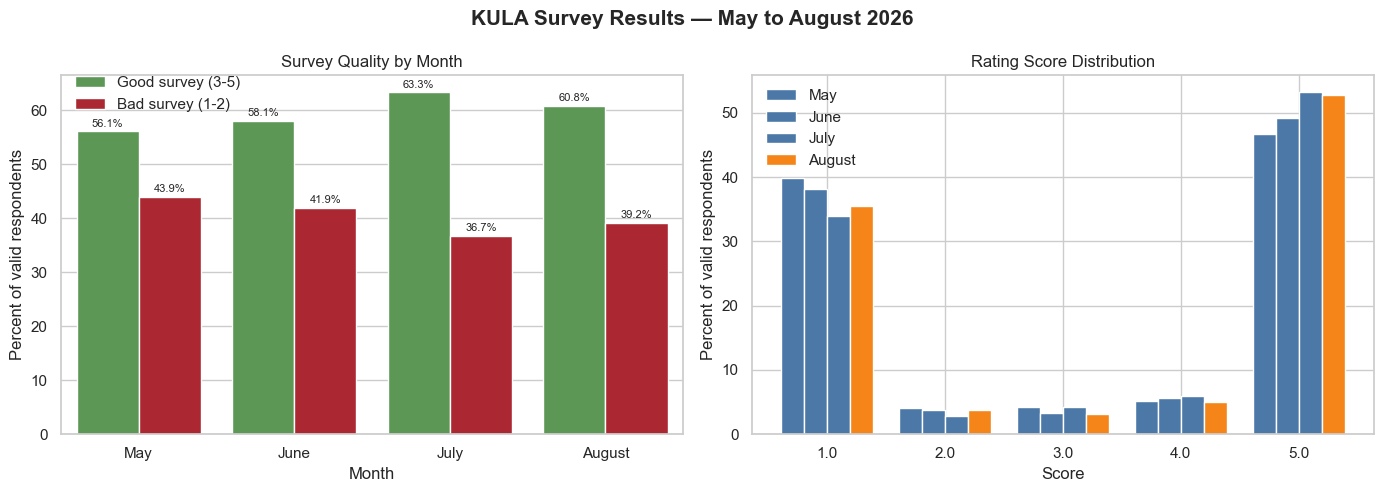

In [30]:
# Monthly survey quality and score distribution.
quality_plot = monthly_summary.loc[['good_survey_%', 'bad_survey_%']].T.reset_index(names='Month')
quality_long = quality_plot.melt(id_vars='Month', var_name='Metric', value_name='Percent')
quality_long['Metric'] = quality_long['Metric'].map({
    'good_survey_%': 'Good survey (3-5)',
    'bad_survey_%': 'Bad survey (1-2)',
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=quality_long, x='Month', y='Percent', hue='Metric', ax=axes[0], palette=['#54A24B', '#c1121f'])
axes[0].set_title('Survey Quality by Month')
axes[0].set_ylabel('Percent of valid respondents')
axes[0].legend(title='', frameon=False, loc='upper left', bbox_to_anchor=(0, 1.037))
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', padding=2, fontsize=8)

rating_distribution.plot(kind='bar', ax=axes[1], color=month_colors, width=0.78)
axes[1].set_title('Rating Score Distribution')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Percent of valid respondents')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(frameon=False, loc='upper left')

fig.suptitle('KULA Survey Results — May to August 2026', fontsize=15, fontweight='bold')
fig.tight_layout()
plt.show()